In [18]:
import pandas as pd
import config, os
from tqdm import tqdm
import matplotlib.pyplot as plt

In [19]:
DATA_PATH = os.path.join(config.DATA_DIR, 'archive', 'FaceForensics++_C23')
CSV_PATH = os.path.join(DATA_PATH, 'csv')
TRAIN_PATH = os.path.join(DATA_PATH, 'training_set')
VAL_PATH = os.path.join(DATA_PATH, 'valdiation_set')

In [20]:
train_df = pd.read_csv(os.path.join(CSV_PATH, 'TRAIN.csv'))
test_df = pd.read_csv(os.path.join(CSV_PATH, 'TEST.csv'))

### 데이터 불균형 해소 후 저장

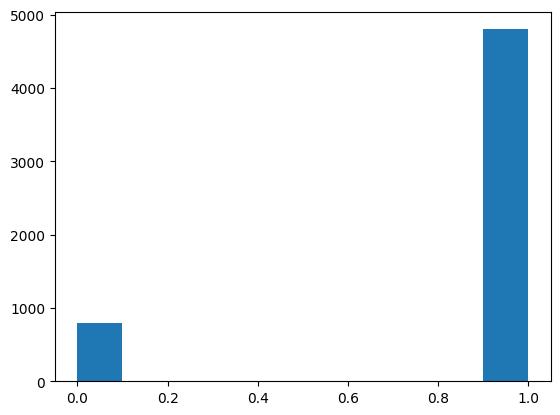

In [21]:
plt.hist(x=train_df.Label_int)
plt.show()

-> original << deepfake

In [22]:
train_df

,File Path,data,crops_path,Label_int
0,original/197.mp4,original,data\archive\FaceForensics++_C23\crops\origina...,0
1,original/972.mp4,original,data\archive\FaceForensics++_C23\crops\origina...,0
2,Deepfakes/923_023.mp4,Deepfakes,data\archive\FaceForensics++_C23\crops\Deepfak...,1
3,FaceSwap/201_203.mp4,FaceSwap,data\archive\FaceForensics++_C23\crops\FaceSwa...,1
4,original/847.mp4,original,data\archive\FaceForensics++_C23\crops\origina...,0
...,...,...,...,...
5595,original/368.mp4,original,data\archive\FaceForensics++_C23\crops\origina...,0
5596,FaceSwap/938_987.mp4,FaceSwap,data\archive\FaceForensics++_C23\crops\FaceSwa...,1
5597,DeepFakeDetection/04_07__kitchen_pan__XRK7FGZX...,DeepFakeDetection,data\archive\FaceForensics++_C23\crops\DeepFak...,1
5598,Face2Face/619_620.mp4,Face2Face,data\archive\FaceForensics++_C23\crops\Face2Fa...,1


In [23]:
train_df_real = train_df[train_df['Label_int'] == 0]
train_df_fake = train_df[train_df['Label_int'] == 1]
train_df_fake_down = train_df_fake.sample(n=len(train_df_real), random_state=42)
train_df_balanced = pd.concat([train_df_real, train_df_fake_down]).sample(frac=1, random_state=42).reset_index(drop=True)

In [24]:
train_df_balanced.to_csv(os.path.join(CSV_PATH, 'BALANCED_TRAIN.csv'), index=False)

In [11]:
train_df_balanced.crops_path[0]

'data\\archive\\FaceForensics++_C23\\crops\\original\\375'